In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [33]:
df= pd.read_csv('data/train.csv')


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df['Age']= df['Age'].fillna(
  df['Age'].median()
)

In [8]:
df= df.drop(columns=['Cabin'])

In [9]:
df['Embarked']= df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

In [10]:
df['Familysize']=(
    df['SibSp']+
    df['Parch']+
    1
)

In [11]:
df['Isalone']=(
    df['Familysize']== 1
)

In [12]:
df['Agegroup']= pd.cut(
    df['Age'],
    bins=[0,12,24,46,56,78,100],
    labels=['child','teen','young adult','adult','old adult','senior']
)

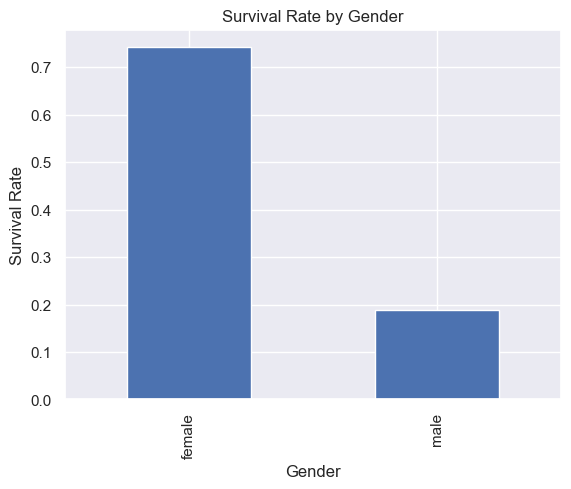

In [34]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')

plt.show()

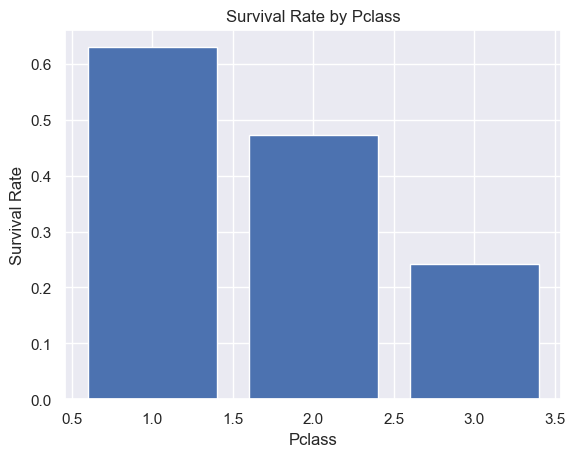

In [35]:
survival_rate = (
    df.groupby('Pclass')['Survived']
    .mean()
)

plt.bar(
    survival_rate.index,
    survival_rate.values
)
plt.title('Survival Rate by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')

plt.show()

Insight:

The rate of survival is depend on the Pclass

The first class buyers have the most rate of survival

In [15]:
df.groupby(
    "Agegroup"
)["Survived"].mean()

Agegroup
child          0.579710
teen           0.375000
young adult    0.360465
adult          0.444444
old adult      0.264706
senior         1.000000
Name: Survived, dtype: float64

In [16]:
df.groupby(
    "Isalone"
)["Survived"].mean()

Isalone
False    0.505650
True     0.303538
Name: Survived, dtype: float64

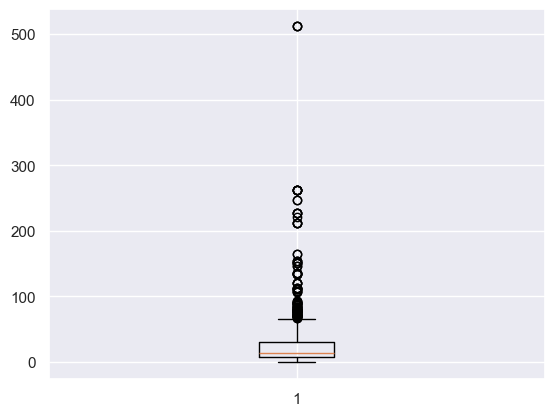

In [ ]:
plt.boxplot(
    df["Fare"]
)

plt.show()

Insight:

Some of the data has a higher range than the most of it

Rich people are less than other type of people

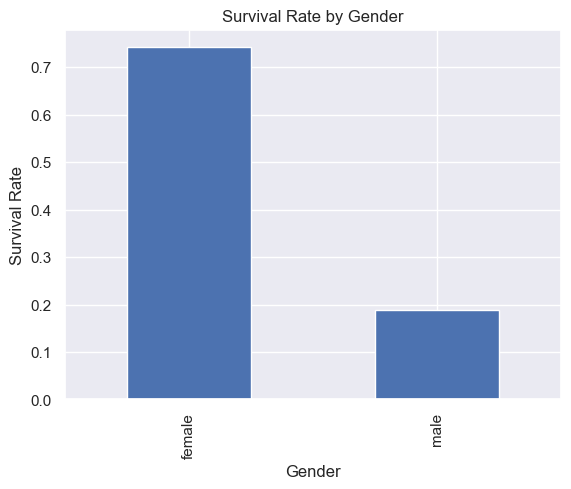

In [18]:
survival_by_sex = (
    df.groupby('Sex')['Survived']
    .mean()
)

survival_by_sex.plot(
    kind='bar'
)

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')

plt.show()

Insight:

Female passengers had a significantly higher survival rate than male passengers.

This suggests that evacuation policies may have prioritized women during the disaster.

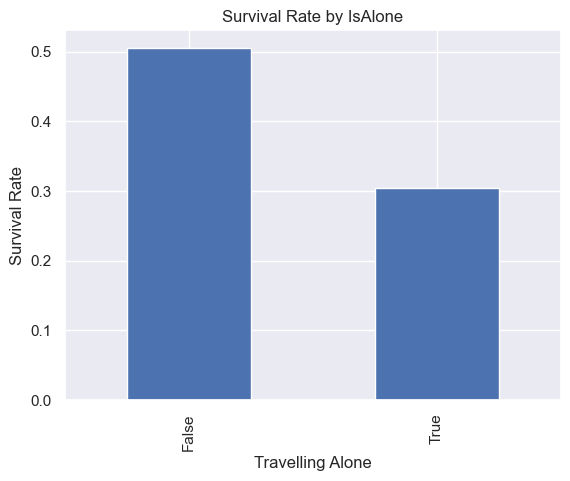

In [19]:
survival_by_alone = (
    df.groupby('Isalone')['Survived']
    .mean()
)

survival_by_alone.plot(
    kind='bar'
)

plt.title('Survival Rate by IsAlone')
plt.xlabel('Travelling Alone')
plt.ylabel('Survival Rate')

plt.show()

Insight:

people who traveled alone has less chance of survivng from the ship

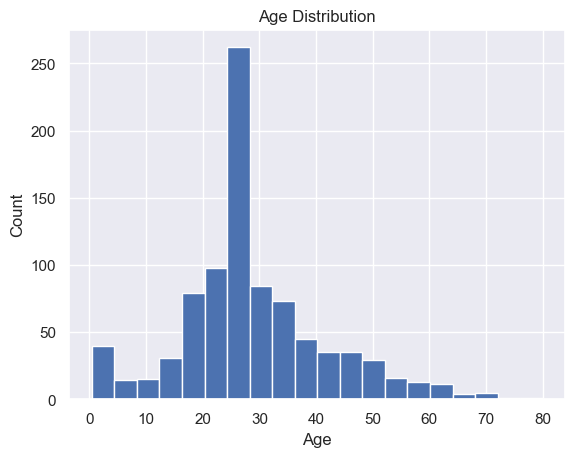

In [20]:
plt.hist(
    df['Age'],
    bins=20
)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

Insight:

This plot shows the range of people survived with their age

Is reveals how important the age decided for survival

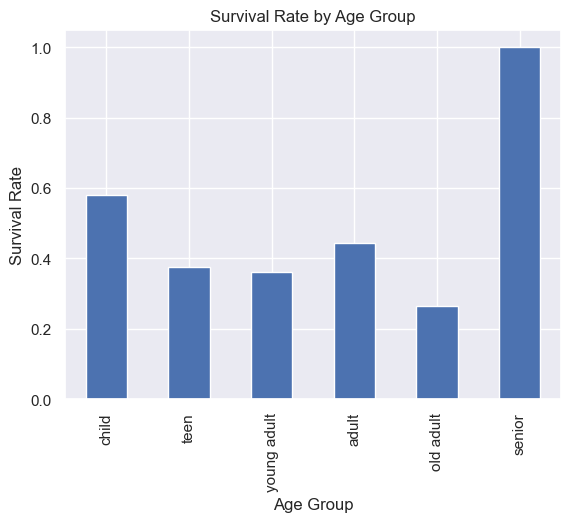

In [21]:
survival_by_age = (
    df.groupby('Agegroup')['Survived']
    .mean()
)

survival_by_age.plot(
    kind='bar'
)

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')

plt.show()

In [22]:
df.groupby('Agegroup').size()

Agegroup
child           69
teen           208
young adult    516
adult           63
old adult       34
senior           1
dtype: int64

Insight:

Children showed higher survival rates compared to most age groups.

The senior category contained only one passenger, therefore conclusions about this group are not reliable.

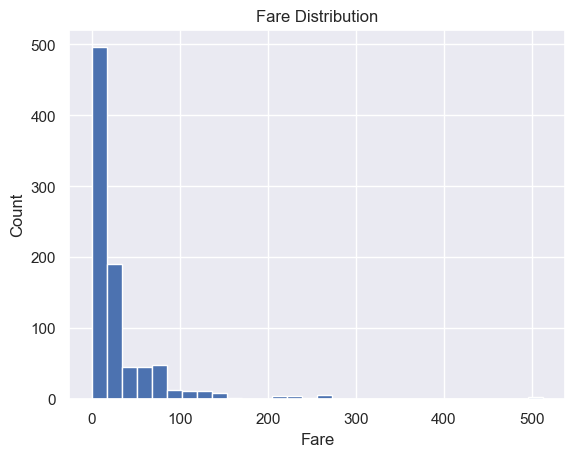

In [23]:
plt.hist(df['Fare'], bins=30)

plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.show()

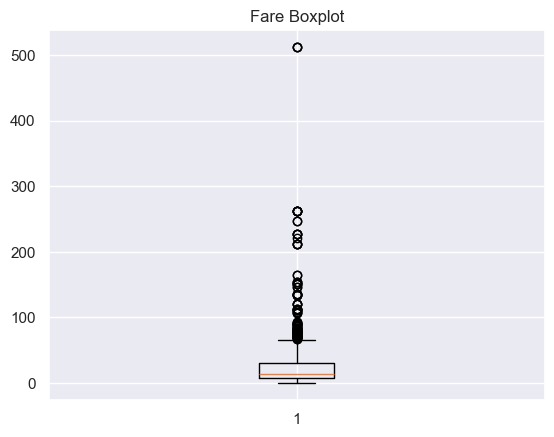

In [24]:
plt.boxplot(df['Fare'])
plt.title('Fare Boxplot')
plt.show()

In [25]:
df['Faregroup'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [26]:
df.groupby('Faregroup')['Survived'].agg(['mean','count'])

,mean,count
Faregroup,,
Low,0.197309,223
Medium,0.303571,224
High,0.454955,222
Very High,0.581081,222


Passengers who paid higher fares generally had higher survival rates. The fare groups contained sufficient numbers of passengers, making this trend more reliable than the senior age group analysis.

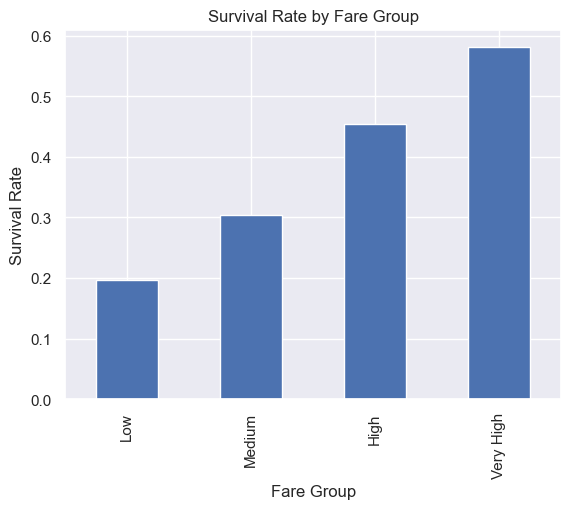

In [27]:
survival_by_fare = (
    df.groupby('Faregroup')['Survived']
    .mean()
)

survival_by_fare.plot(
    kind='bar'
)

plt.title('Survival Rate by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate')

plt.show()

In [28]:
numeric_df = df.select_dtypes(include=['int64','float64'])

In [29]:
numeric_df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Familysize
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
Familysize,-0.040143,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000


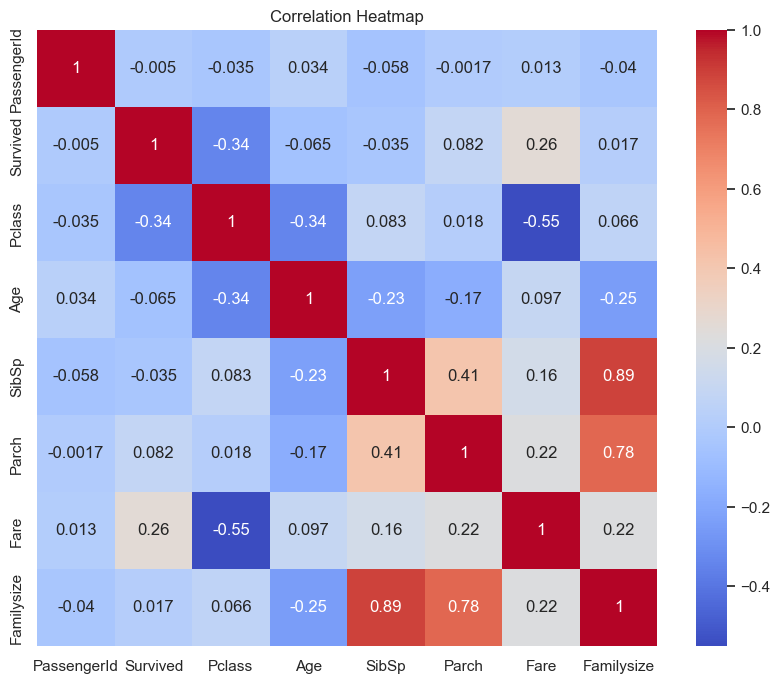

In [30]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

Correlation analysis showed that Fare had a positive relationship with survival, while Pclass showed a negative relationship. Age demonstrated a relatively weak correlation with survival.

In [31]:
numeric_df.corr()['Survived'].sort_values(
    ascending=False
)

Survived       1.000000
Fare           0.257307
Parch          0.081629
Familysize     0.016639
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481
Name: Survived, dtype: float64

Female passengers had a significantly higher survival rate than male passengers.

First-class passengers were more likely to survive than third-class passengers.

Passengers with higher fares generally showed higher survival rates.

Children tended to have higher survival rates than most adult groups.

Passengers traveling alone generally had lower survival rates.

# Conclusion

The analysis indicates that passenger class, gender, and fare were the strongest factors associated with survival.

Female passengers and first-class travelers had the highest survival rates, while passengers traveling alone generally faced lower survival chances.

Age showed a weaker relationship with survival compared to gender and passenger class.